# Sleep Disorder Prediction
Using SVM with SMOTE and GridSearchCV on the Sleep Health and Lifestyle Dataset

## 1. Imports

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

## 2. Load Data

In [41]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df = df.drop('Person ID', axis=1)
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [42]:
print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isna().sum())

Shape: (374, 12)

Data Types:
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

Missing Values:
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


## 3. Exploratory Data Analysis (EDA)

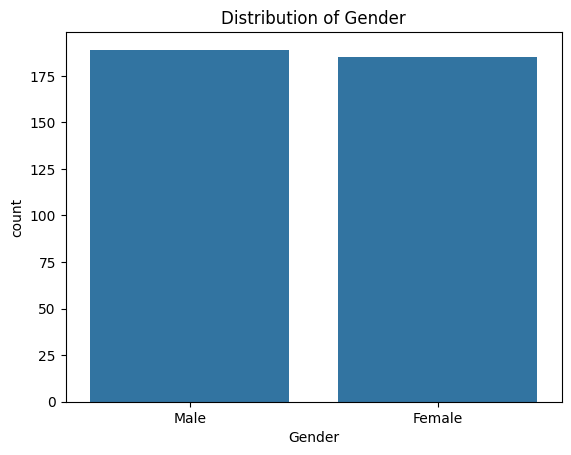

In [43]:
# Gender distribution
sns.countplot(x='Gender', data=df)
plt.title('Distribution of Gender')
plt.show()

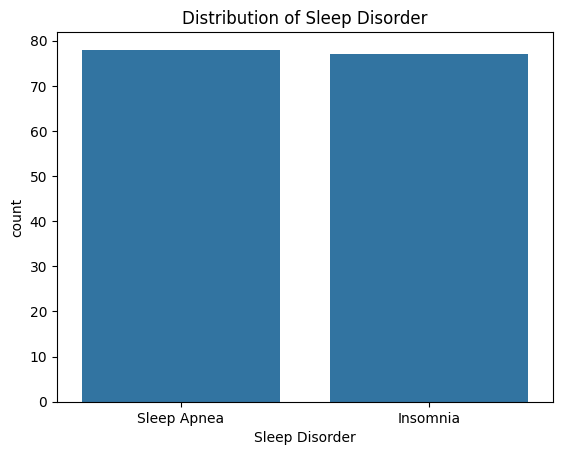

In [44]:
#Sleep Disorder distribution
sns.countplot(x='Sleep Disorder', data=df)
plt.title('Distribution of Sleep Disorder')
plt.show()

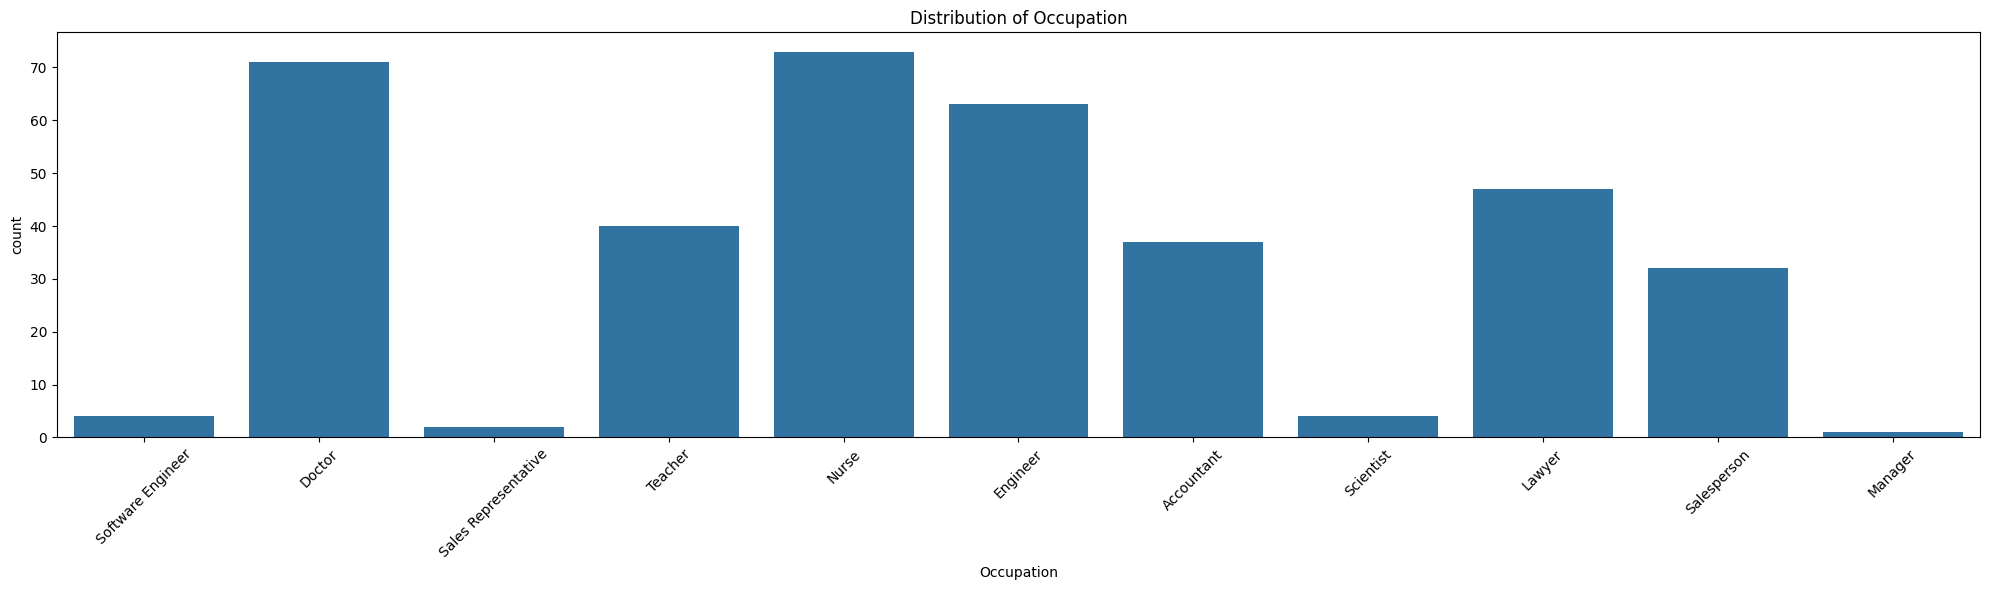

In [45]:
# Occupation distribution
plt.figure(figsize=(20, 6))
sns.countplot(x='Occupation', data=df)
plt.title('Distribution of Occupation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We noticed redundancy in "Software Engineer" and "Engineer".

Also, some occupations such as "Manager" have notably low counts.

Both issues will be addressed in the data preprocessing step

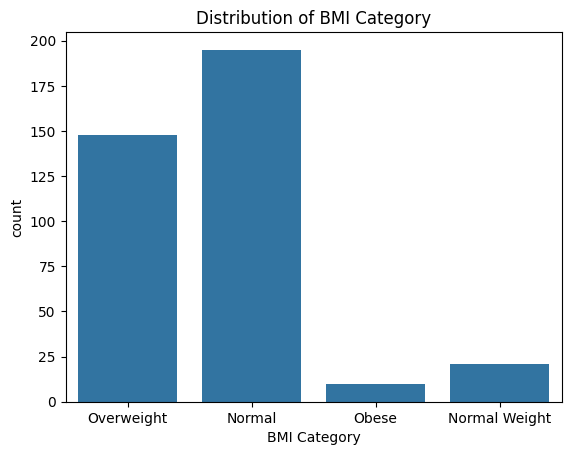

In [46]:
# BMI Category distribution
sns.countplot(x='BMI Category', data=df)
plt.title('Distribution of BMI Category')
plt.show()

we can see redundancy in Normal - Normal Weight: this will be addressed in preprocessing step

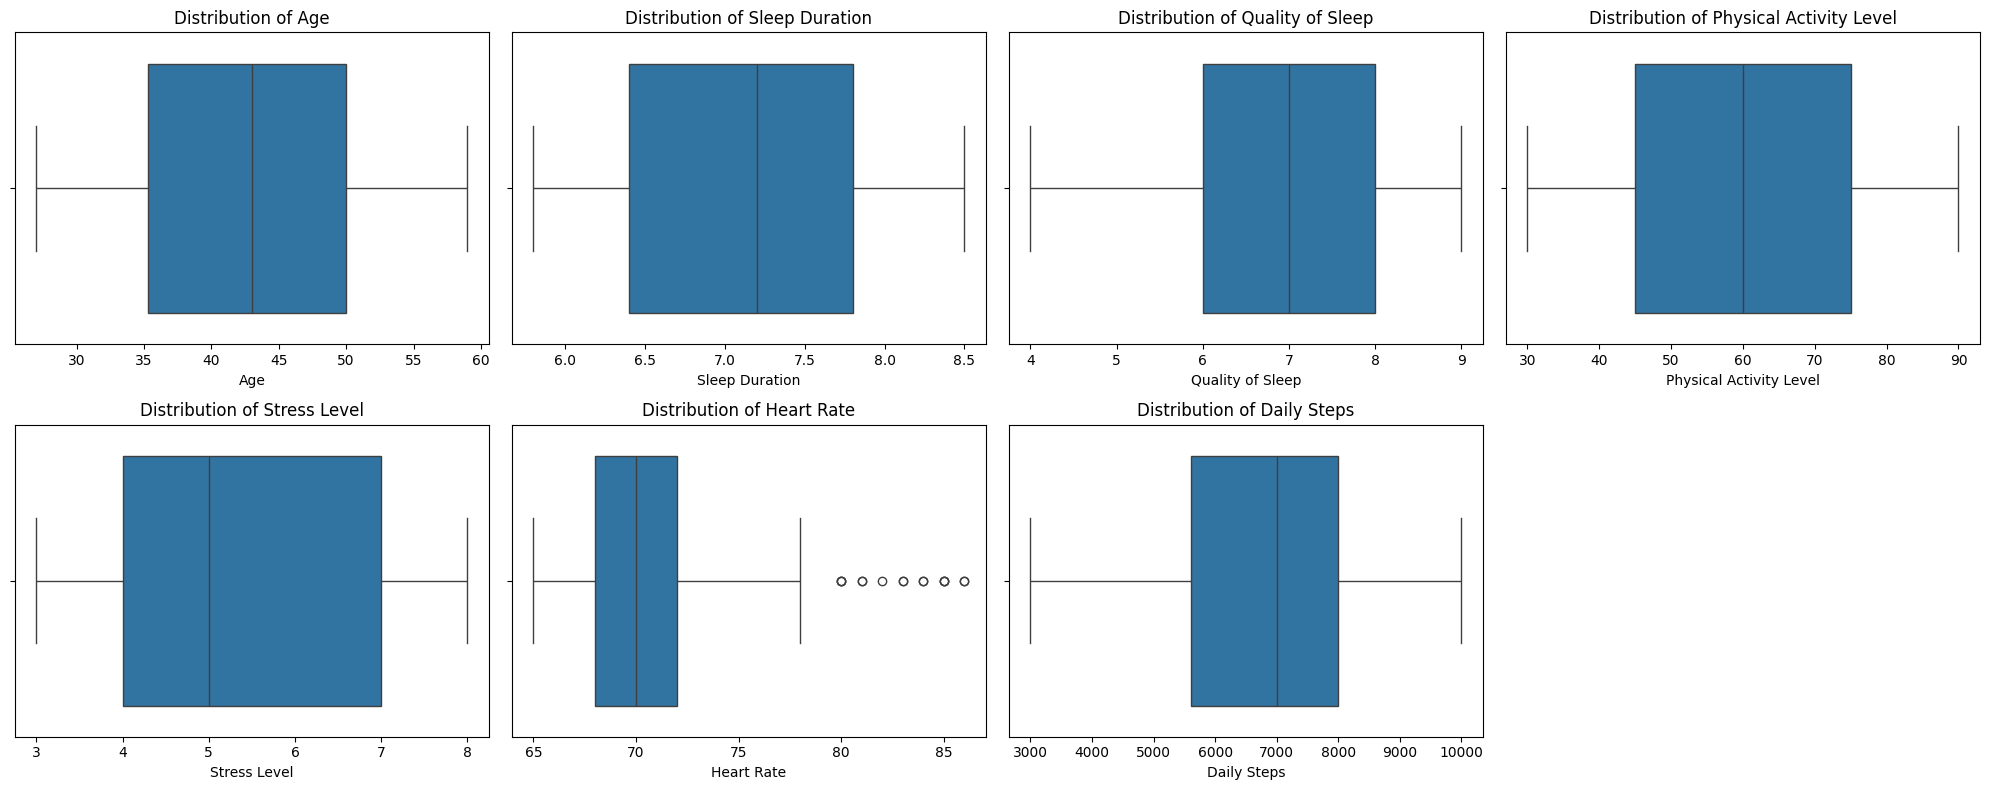

In [47]:
# Numerical features - box plots
numerical_features = ['Age', 'Sleep Duration', 'Quality of Sleep',
                      'Physical Activity Level', 'Stress Level',
                      'Heart Rate', 'Daily Steps']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')

axes[-1].set_visible(False)  # hide empty last subplot
plt.tight_layout()
plt.show()

We can see outliers in the Heart Rate boxplot: we will address this in the preprocessing step

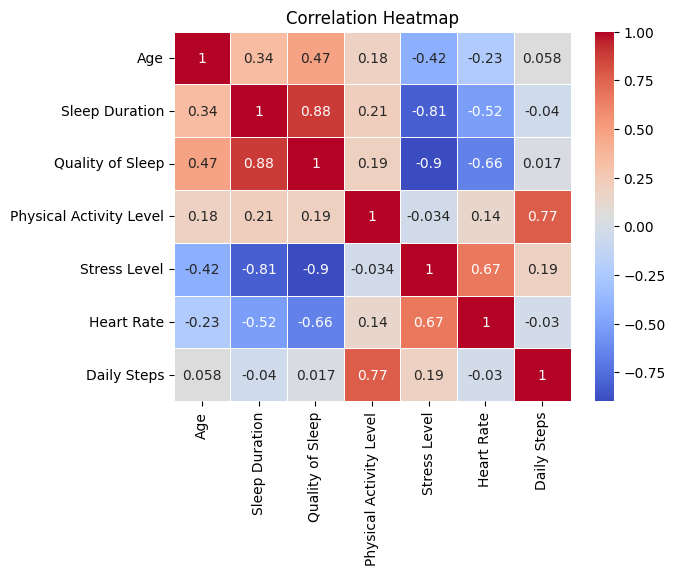

In [48]:
numericals = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numericals].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

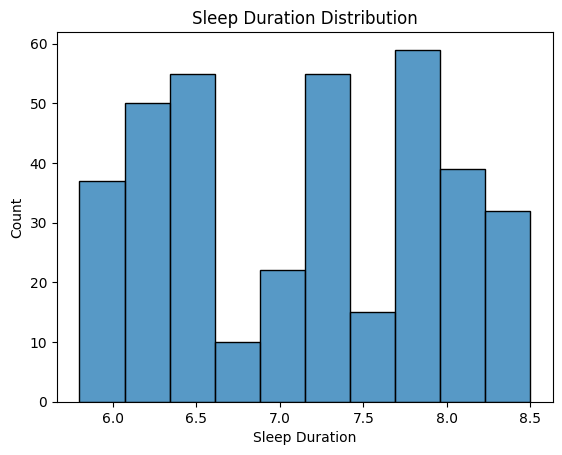

In [49]:
# Sleep Duration histogram
sns.histplot(df, x='Sleep Duration')
plt.title('Sleep Duration Distribution')
plt.show()

## 4. Data Preprocessing

In [50]:
# Fix inconsistent BMI Category labels
df = df.replace('Normal Weight', 'Normal')
print('BMI Category counts:')
print(df['BMI Category'].value_counts())

BMI Category counts:
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64


In [51]:
# Fix inconsistent and low-sample Occupation labels
df = df.replace('Software Engineer', 'Engineer')

occupation_map = {
    'Scientist': 'Other',
    'Manager': 'Other',
    'Sales Representative': 'Other'
}

df['Occupation'] = df['Occupation'].replace(occupation_map)

print('Occupation counts:')
print(df['Occupation'].value_counts())

Occupation counts:
Occupation
Nurse          73
Doctor         71
Engineer       67
Lawyer         47
Teacher        40
Accountant     37
Salesperson    32
Other           7
Name: count, dtype: int64


In [52]:
#Examine Blood Pressure outliers
print(df[df['Heart Rate'] > 80]['Sleep Disorder'].value_counts())

Sleep Disorder
Sleep Apnea    8
Insomnia       4
Name: count, dtype: int64


Since they are correlated with sleep diseases, they are most likely relevant to our model. Therefore, we will keep them as is.

In [53]:
# Encode target variable
df['Sleep Disorder'] = df['Sleep Disorder'].map({'None': 0, 'Insomnia': 1, 'Sleep Apnea': 2})
df['Sleep Disorder'] = df['Sleep Disorder'].fillna(0)

In [54]:
# Split Blood Pressure into systolic and diastolic
df[['BP_Systolic', 'BP_Diastolic']] = (
    df['Blood Pressure']
    .str.split('/', expand=True)
    .astype(int)
)
df.drop('Blood Pressure', axis=1, inplace=True)

In [55]:
# Encode Gender
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [56]:
# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Occupation', 'BMI Category'], dtype=int)

In [57]:
# Remove duplicates: this step is reducing our accuracy from 92-93 to 78, but it is necessary to ensure our model is not overfitting to duplicate records.
df.drop_duplicates(inplace=True)
print('Final shape:', df.shape)
df.head()

Final shape: (132, 22)


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,BP_Systolic,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Nurse,Occupation_Other,Occupation_Salesperson,Occupation_Teacher,BMI Category_Normal,BMI Category_Obese,BMI Category_Overweight
0,0,27,6.1,6,42,6,77,4200,0.0,126,...,0,1,0,0,0,0,0,0,0,1
1,0,28,6.2,6,60,8,75,10000,0.0,125,...,1,0,0,0,0,0,0,1,0,0
3,0,28,5.9,4,30,8,85,3000,2.0,140,...,0,0,0,0,1,0,0,0,1,0
5,0,28,5.9,4,30,8,85,3000,1.0,140,...,0,1,0,0,0,0,0,0,1,0
6,0,29,6.3,6,40,7,82,3500,1.0,140,...,0,0,0,0,0,0,1,0,1,0


## 5. Train Test Split

In [58]:
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=10, stratify=y
)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)
print('\nClass distribution in training set:')
print(y_train.value_counts())

Training set size: (105, 21)
Test set size: (27, 21)

Class distribution in training set:
Sleep Disorder
0.0    58
2.0    24
1.0    23
Name: count, dtype: int64


## 6. Model Training + Parameter Plotting

In [59]:
# Using pipeline instead of separate scaling, since scaling allows the model to look at all of the training data,
# which should be split into train and test in the kfold
# hence, the pipeline prevents the model from looking at the testing data within the training set
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC())
])

# Hyperparameter grid
param_grid = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__gamma': [1, 0.1, 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear', 'poly', 'sigmoid']
}

# Stratified K-Fold cross validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search
grid = GridSearchCV(pipeline, param_grid, refit=True, verbose=2, cv=kfold, scoring='accuracy')
grid.fit(X_train, y_train)

print('\nBest Parameters:', grid.best_params_)
print('Best CV Accuracy:', grid.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] END .........svm__C=0.01, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END .........svm__C=0.01, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END .........svm__C=0.01, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END .........svm__C=0.01, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END .........svm__C=0.01, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END ......svm__C=0.01, svm__gamma=1, svm__kernel=linear; total time=   0.0s
[CV] END ......svm__C=0.01, svm__gamma=1, svm__kernel=linear; total time=   0.0s
[CV] END ......svm__C=0.01, svm__gamma=1, svm__kernel=linear; total time=   0.0s
[CV] END ......svm__C=0.01, svm__gamma=1, svm__kernel=linear; total time=   0.0s
[CV] END ......svm__C=0.01, svm__gamma=1, svm__kernel=linear; total time=   0.0s
[CV] END ........svm__C=0.01, svm__gamma=1, svm__kernel=poly; total time=   0.0s
[CV] END ........svm__C=0.01, svm__gamma=1, svm

In [60]:
results = pd.DataFrame(grid.cv_results_)

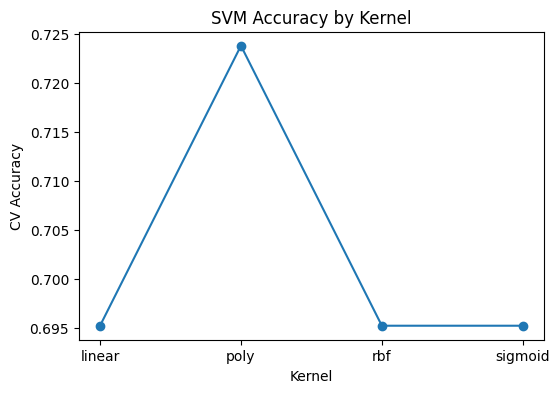

In [61]:
kernel_scores = results.groupby('param_svm__kernel')['mean_test_score'].max()
plt.figure(figsize=(6, 4))
plt.plot(kernel_scores.index, kernel_scores.values, marker='o')
plt.xlabel('Kernel')
plt.ylabel('CV Accuracy')
plt.title('SVM Accuracy by Kernel')
plt.savefig('svm_kernel_comparison_plot.png')
plt.show()

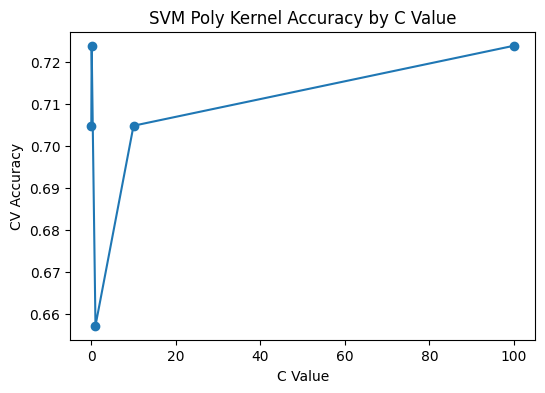

In [62]:
poly_rows = results[results['param_svm__kernel'] == 'poly']
c_scores = poly_rows.groupby('param_svm__C')['mean_test_score'].max()
plt.figure(figsize=(6,4))
plt.plot(c_scores.index, c_scores.values, marker='o')
plt.xlabel('C Value')
plt.ylabel('CV Accuracy')
plt.title('SVM Poly Kernel Accuracy by C Value')
plt.savefig('svm_poly_c_comparison.png')

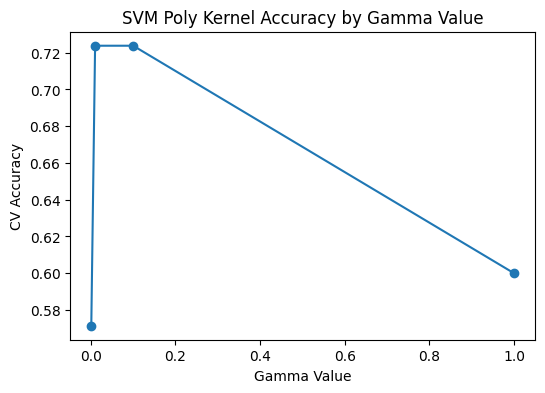

In [63]:
gamma_scores = poly_rows.groupby('param_svm__gamma')['mean_test_score'].max()
plt.figure(figsize=(6,4))
plt.plot(gamma_scores.index, gamma_scores.values, marker='o')
plt.xlabel('Gamma Value')
plt.ylabel('CV Accuracy')
plt.title('SVM Poly Kernel Accuracy by Gamma Value')
plt.savefig('svm_poly_gamma_comparison.png')

## 7. Evaluation

In [64]:
predictions = grid.predict(X_test)

print('Accuracy:', accuracy_score(y_test, predictions))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, predictions))
print('\nClassification Report:')
print(classification_report(y_test, predictions))
print('\nBest CV Accuracy:', grid.best_score_)

Accuracy: 0.7777777777777778

Confusion Matrix:
[[12  2  1]
 [ 1  4  1]
 [ 0  1  5]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.80      0.86        15
         1.0       0.57      0.67      0.62         6
         2.0       0.71      0.83      0.77         6

    accuracy                           0.78        27
   macro avg       0.74      0.77      0.75        27
weighted avg       0.80      0.78      0.78        27


Best CV Accuracy: 0.7238095238095238


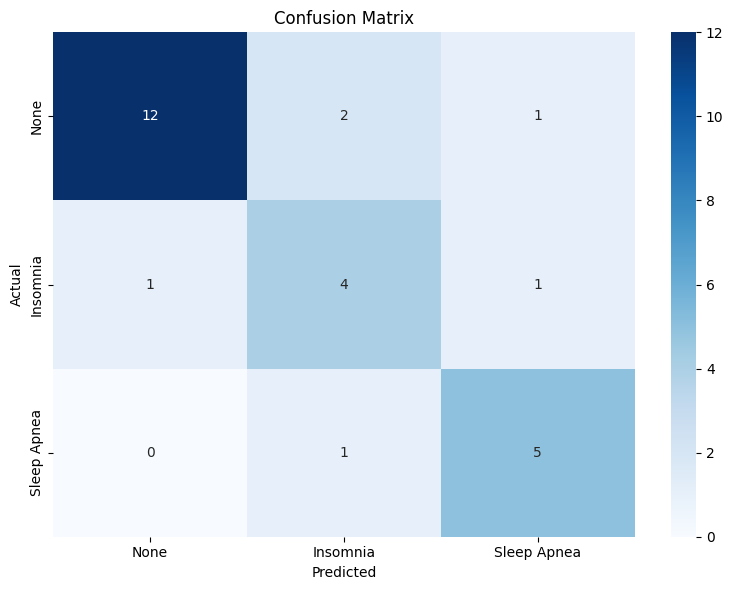

In [65]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, predictions),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['None', 'Insomnia', 'Sleep Apnea'],
    yticklabels=['None', 'Insomnia', 'Sleep Apnea']
)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 8. Feature Selection using RFECV

In [66]:
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# RFECV needs a model that can rank features.
# Since the final best SVM uses RBF kernel, we use a linear SVM only for feature selection.
feature_selector_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(kernel='linear'))
])

rfecv = RFECV(
    estimator=feature_selector_pipeline,
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    importance_getter='named_steps.svm.coef_',
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

selected_features = X_train.columns[rfecv.support_].tolist()

print("Optimal number of features:", rfecv.n_features_)
print("Selected features:")
print(selected_features)

Optimal number of features: 8
Selected features:
['Sleep Duration', 'Quality of Sleep', 'Heart Rate', 'Daily Steps', 'BP_Systolic', 'BP_Diastolic', 'Occupation_Doctor', 'Occupation_Other']


## 9. Feature Selection Plot

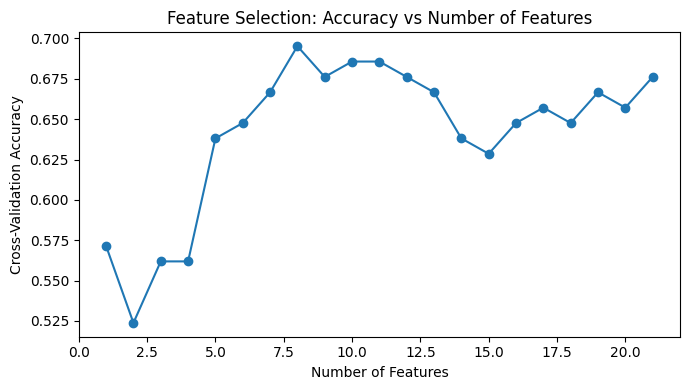

In [67]:
plt.figure(figsize=(7, 4))
plt.plot(
    range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
    rfecv.cv_results_['mean_test_score'],
    marker='o'
)

plt.xlabel('Number of Features')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Feature Selection: Accuracy vs Number of Features')
plt.tight_layout()
plt.savefig('feature_selection.png', dpi=150)
plt.show()

## 10. SVM Performance with Different Feature Sets

In [69]:
# Best V/2 features based on correlation with target
corr_data = X_train.copy()
corr_data['target'] = y_train

correlations = corr_data.corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)

v2_count = max(1, X_train.shape[1] // 2)
best_v2_features = correlations.head(v2_count).index.tolist()

print("Best V/2 features:")
print(best_v2_features)

def evaluate_svm_features(feature_list, feature_set_name):
    best_params = grid.best_params_

    svm_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('svm', SVC(
            C=best_params['svm__C'],
            gamma=best_params['svm__gamma'],
            kernel=best_params['svm__kernel']
        ))
    ])

    # Train model
    svm_pipeline.fit(X_train[feature_list], y_train)

    # Test prediction
    pred = svm_pipeline.predict(X_test[feature_list])

    # Cross-validation on the same feature subset
    cv_scores = cross_val_score(
        svm_pipeline,
        X_train[feature_list],
        y_train,
        cv=kfold,
        scoring='accuracy'
    )

    return {
        'Feature Set': feature_set_name,
        'Model': 'SVM',
        'Number of Features': len(feature_list),
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'CV Average Accuracy': round(cv_scores.mean(), 6),
        'CV Standard Deviation': round(cv_scores.std(), 6),
        'Precision': round(precision_score(y_test, pred, average='weighted', zero_division=0), 4),
        'Recall': round(recall_score(y_test, pred, average='weighted', zero_division=0), 4),
        'F1-score': round(f1_score(y_test, pred, average='weighted', zero_division=0), 4)
    }

svm_feature_results = pd.DataFrame([
    evaluate_svm_features(X_train.columns.tolist(), 'All Features'),
    evaluate_svm_features(best_v2_features, 'Best V/2 Features'),
    evaluate_svm_features(selected_features, 'RFECV-selected Features')
])

svm_feature_results

Best V/2 features:
['BP_Diastolic', 'BP_Systolic', 'BMI Category_Normal', 'BMI Category_Overweight', 'Heart Rate', 'Occupation_Nurse', 'Quality of Sleep', 'Sleep Duration', 'Occupation_Engineer', 'BMI Category_Obese']


,Feature Set,Model,Number of Features,Accuracy,CV Average Accuracy,CV Standard Deviation,Precision,Recall,F1-score
0,All Features,SVM,21,0.7778,0.723810,0.019048,0.7985,0.7778,0.7839
1,Best V/2 Features,SVM,10,0.8148,0.647619,0.133333,0.8369,0.8148,0.8201
2,RFECV-selected Features,SVM,8,0.7407,0.419048,0.139321,0.7353,0.7407,0.7179
